# Siamese Network Training

This notebook **fine-tunes ResNet50** using a **Triplet Loss** objective to learn a specialized 128-dimensional embedding space where:

- Photos of the **same cow** map to nearby vectors.
- Photos of **different cows** map to distant vectors.

This is the core training step that transforms a generic vision model into a cattle biometric identifier.

## Imports

Same libraries as the baseline, plus three training-specific additions:

- `tqdm`: live progress bar during the training loop.
- `Dataset` / `DataLoader`: PyTorch's data pipeline API for batching and shuffling.
- `torch.optim`: optimization algorithms (Adam is used here).

In [1]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

## Device Selection

Auto-detect GPU availability and fall back to CPU if none is present.

> More robust than the baseline's hard-coded `cuda`; this pattern is safe to run on any machine.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

## Image Preprocessing Pipeline

Same two-step transform as the baseline:

1. `Resize((224, 224))`: standardize all images to ResNet50's required input size.
2. `ToTensor()`: convert PIL Image to a float32 PyTorch tensor in `[C, H, W]` format.

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## Build Dataset Dictionary

Scan the dataset folder and build `cattle_data`: a dict mapping each cow ID to its list of image paths.

- Only cows with **≥ 2 images** are kept, triplet sampling requires at least two images per identity.
- This structure is passed directly into `TripletDataset` in the next cell.

In [4]:
DATASET_PATH = "../data/raw/BeefCattle_Muzzle"

cattle_data = {}

for cattle_id in os.listdir(DATASET_PATH):

    cattle_folder = os.path.join(DATASET_PATH, cattle_id)

    if os.path.isdir(cattle_folder):

        images = []

        for img_name in os.listdir(cattle_folder):
            img_path = os.path.join(cattle_folder, img_name)

            images.append(img_path)

        if len(images) >= 2:
            cattle_data[cattle_id] = images

print("Total cattle:", len(cattle_data))

Total cattle: 268


## `TripletDataset` Class

Custom PyTorch `Dataset` that generates **(anchor, positive, negative)** triplets on-the-fly.

**Triplet definition:**
| Image | Description |
|-------|-------------|
| Anchor | Photo A of cow X |
| Positive | Photo B of the **same** cow X |
| Negative | Photo of a **different** cow Y |

**Key design decisions:**
- `__len__` returns `5000`, a virtual size; triplets are randomly generated on each access (online mining).
- The `while` loop re-samples until `negative_class != anchor_class`, preventing accidental same-cow negatives.
- `random.sample(..., 2)` for anchor/positive ensures the two images are **distinct** (no image compared to itself).

In [5]:
class TripletDataset(Dataset):

    def __init__(self, cattle_data, transform=None):
        self.cattle_data = cattle_data
        self.transform = transform

        self.cattle_ids = list(cattle_data.keys())

    def __len__(self):
        return 5000

    def __getitem__(self, idx):

        # Anchor class
        anchor_class = random.choice(self.cattle_ids)

        # Negative class
        negative_class = random.choice(self.cattle_ids)

        while negative_class == anchor_class:
            negative_class = random.choice(self.cattle_ids)

        # Same cow images
        anchor_img_path, positive_img_path = random.sample(
            self.cattle_data[anchor_class],
            2
        )

        # Different cow image
        negative_img_path = random.choice(
            self.cattle_data[negative_class]
        )

        # Load images
        anchor_img = Image.open(anchor_img_path).convert("RGB")
        positive_img = Image.open(positive_img_path).convert("RGB")
        negative_img = Image.open(negative_img_path).convert("RGB")

        # Transform
        if self.transform:
            anchor_img = self.transform(anchor_img)
            positive_img = self.transform(positive_img)
            negative_img = self.transform(negative_img)

        return anchor_img, positive_img, negative_img

## Instantiate Dataset and DataLoader

Wrap the dataset in a `DataLoader` for batched, shuffled iteration during training.

- `batch_size=16`: processes 16 triplets per gradient step; balances GPU memory usage vs. training stability.
- `shuffle=True`: randomizes the order of the 5000 virtual indices each epoch (since `__getitem__` already samples randomly, the practical effect is minor but follows best practice).

In [6]:
triplet_dataset = TripletDataset(
    cattle_data,
    transform=transform
)

train_loader = DataLoader(
    triplet_dataset,
    batch_size=16,
    shuffle=True
)

## `SiameseNetwork` Class

Define the model architecture. Despite the name, a Siamese network is a **single shared network** applied to all three inputs; not three separate networks.

- `backbone`: ResNet50 pretrained on ImageNet; all convolutional layers are reused.
- `backbone.fc = nn.Linear(2048, 128)`: replaces the 1000-class head with a **128-dimensional projection layer**.
  - 128 dims (vs. 2048 in baseline): more compact, better generalization, faster comparison.
- `forward(x)`: simply runs the full backbone and returns the 128-dim embedding.

In [7]:
class SiameseNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        # Remove classifier
        self.backbone.fc = nn.Linear(2048, 128)

    def forward(self, x):
        embedding = self.backbone(x)

        return embedding

## Instantiate Model

Create the `SiameseNetwork` and move it to the selected device (GPU/CPU). Jupyter prints the full architecture tree for inspection.

In [8]:
model = SiameseNetwork().to(device)

model

SiameseNetwork(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
  

## Loss Function: Triplet Margin Loss

Define the training objective.

**Triplet Margin Loss formula:**
```
L = max(0, d(anchor, positive) - d(anchor, negative) + margin)
```

- The loss is zero when the negative is already `margin` farther from the anchor than the positive.
- `margin=1.0`: the minimum desired gap between same-cow distance and different-cow distance.
- `p=2`: uses **Euclidean (L2) distance** to measure separation in embedding space.

In [9]:
criterion = nn.TripletMarginLoss(
    margin=1.0,
    p=2
)

## Optimizer

Use the **Adam** optimizer to update model weights during training.

- `model.parameters()`: tells Adam which tensors to update (all learnable weights and biases).
- `lr=0.0001`: a conservative learning rate well-suited for fine-tuning a pretrained model; a larger rate risks destroying the pretrained features.

In [10]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

## Training Loop

The main training loop; runs for 5 epochs over 5000 triplets each.

**Each batch iteration:**
1. Move anchor, positive, and negative batches to GPU.
2. `optimizer.zero_grad()`: clear stale gradients from the previous step.
3. Forward pass through the shared network to produce three sets of embeddings.
4. Compute Triplet Margin Loss.
5. `loss.backward()`: backpropagate gradients through the entire network.
6. `optimizer.step()`: update weights in the direction that reduces loss.

The `tqdm` progress bar shows live loss per batch; epoch average loss is printed at the end of each epoch.

In [11]:
EPOCHS = 5

model.train()

for epoch in range(EPOCHS):

    running_loss = 0.0

    loop = tqdm(train_loader)

    for anchor, positive, negative in loop:

        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        # Generate embeddings
        anchor_emb = model(anchor)
        positive_emb = model(positive)
        negative_emb = model(negative)

        # Compute loss
        loss = criterion(
            anchor_emb,
            positive_emb,
            negative_emb
        )

        # Backprop
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

Epoch [1/5]: 100%|██████████| 313/313 [04:56<00:00,  1.06it/s, loss=0]       


Epoch 1 Average Loss: 0.0565


Epoch [2/5]: 100%|██████████| 313/313 [04:34<00:00,  1.14it/s, loss=0.0139]  


Epoch 2 Average Loss: 0.0133


Epoch [3/5]: 100%|██████████| 313/313 [04:29<00:00,  1.16it/s, loss=0]       


Epoch 3 Average Loss: 0.0105


Epoch [4/5]: 100%|██████████| 313/313 [04:36<00:00,  1.13it/s, loss=0]       


Epoch 4 Average Loss: 0.0064


Epoch [5/5]: 100%|██████████| 313/313 [04:37<00:00,  1.13it/s, loss=0]       

Epoch 5 Average Loss: 0.0066


## Save Model Weights

Persist the trained model to disk.

- `model.state_dict()`: a dictionary of all learnable parameter tensors (weights and biases).
- Only the weights are saved, not the architecture, the `SiameseNetwork` class definition must be available when loading.
- `.pth` is the conventional PyTorch model file extension.

In [12]:
torch.save(
    model.state_dict(),
    "../models/siamese_model.pth"
)

print("Model Saved")

Model Saved


## Reload Model for Evaluation

Load the saved weights back into a fresh `SiameseNetwork` instance and switch to inference mode.

- `load_state_dict()` restores the exact parameter values from training.
- `.eval()` is critical here; without it, batch norm layers would behave as if still training, producing inconsistent embeddings.

In [13]:
model = SiameseNetwork().to(device)

model.load_state_dict(
    torch.load("../models/siamese_model.pth")
)

model.eval()

print("Model Loaded")

Model Loaded


## `get_embedding()` Function (Post-Training)

Same embedding function as the baseline. The key difference is this now runs through the **trained** Siamese network, producing 128-dim vectors in a cattle-specific embedding space rather than the 2048-dim generic ImageNet space.

In [14]:
def get_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = model(image)

    return embedding.cpu().numpy()

## Collect 100 Same-Cow Similarity Scores (Trained Model)

Same evaluation as the baseline: randomly pick 100 same-cow image pairs and measure cosine similarity.

After training, these scores should be **significantly higher** than the baseline's same-cow mean, confirming the model has learned to cluster same-cow photos together.

In [15]:
same_similarities = []

cattle_ids = list(cattle_data.keys())

for _ in range(100):

    cattle_id = random.choice(cattle_ids)

    images = cattle_data[cattle_id]

    img1_path, img2_path = random.sample(images, 2)

    emb1 = get_embedding(img1_path)
    emb2 = get_embedding(img2_path)

    sim = cosine_similarity(emb1, emb2)[0][0]

    same_similarities.append(sim)

print("Same-cow pairs tested:", len(same_similarities))

Same-cow pairs tested: 100


## Collect 100 Different-Cow Similarity Scores (Trained Model)

Same evaluation as the baseline for the negative distribution.

After training, these scores should be **significantly lower** than the baseline's different-cow mean, confirming the model has learned to push different identities apart in embedding space.

In [16]:
different_similarities = []

for _ in range(100):

    cattle_id1, cattle_id2 = random.sample(cattle_ids, 2)

    img1_path = random.choice(cattle_data[cattle_id1])
    img2_path = random.choice(cattle_data[cattle_id2])

    emb1 = get_embedding(img1_path)
    emb2 = get_embedding(img2_path)

    sim = cosine_similarity(emb1, emb2)[0][0]

    different_similarities.append(sim)

print("Different-cow pairs tested:", len(different_similarities))

Different-cow pairs tested: 100


## Print Summary Statistics (Trained Model)

Compare the trained model's statistics against the baseline.

**Expected improvement:**
| Metric | Baseline | Trained |
|--------|----------|---------|
| Same-cow mean | lower | **higher** |
| Different-cow mean | higher | **lower** |
| Separation gap | small | **large** |

### Same Cow

In [17]:
print("Mean:", np.mean(same_similarities))
print("Min :", np.min(same_similarities))
print("Max :", np.max(same_similarities))

Mean: 0.935258
Min : 0.24305052
Max : 0.99367917


### Different Cow

In [18]:
print("Mean:", np.mean(different_similarities))
print("Min :", np.min(different_similarities))
print("Max :", np.max(different_similarities))

Mean: 0.1563636
Min : -0.57475066
Max : 0.9371778


## Plot Similarity Distributions (Trained Model)

Visualize the trained model's same-cow vs. different-cow similarity distributions.

**What success looks like:** Two clearly separated peaks with minimal overlap; a high-similarity cluster (same cow) and a low-similarity cluster (different cows). Compare visually against the baseline histogram: the separation should be dramatically improved.

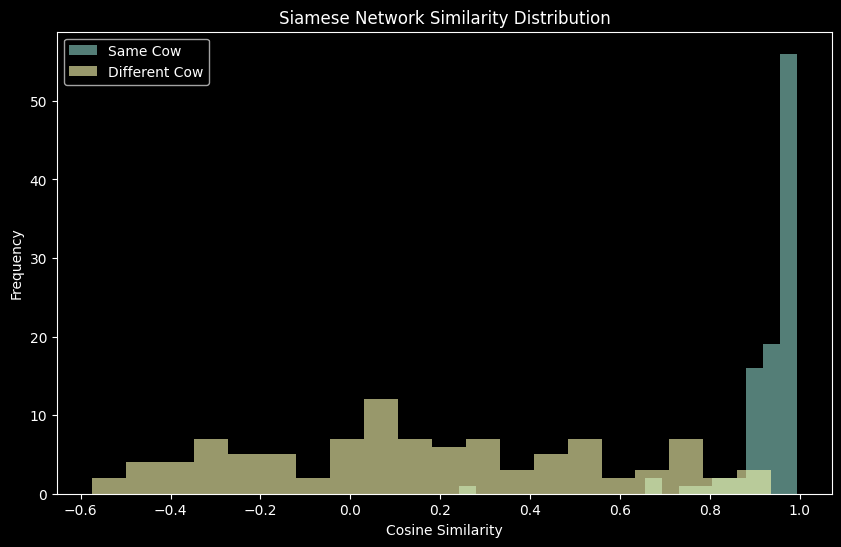

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(
    same_similarities,
    bins=20,
    alpha=0.6,
    label="Same Cow"
)

plt.hist(
    different_similarities,
    bins=20,
    alpha=0.6,
    label="Different Cow"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Siamese Network Similarity Distribution")

plt.legend()

plt.show()